# Исследование 2. Клиентская база и повторные покупки

## Бизнес-задача
Найти направления работы с существующими клиентами: кого возвращать, кому помогать совершить следующую покупку и как измерять эффект без подмены LTV годовой выручкой.

Адресаты — CRM-менеджер и руководитель маркетплейса. Результат — сегменты с размером и денежным вкладом, когортная картина, предложения по двум контролируемым кампаниям и требования к дополнительным данным.

## Данные и ограничения
Источник: учебный API `http://final-project.simulative.ru/data`, по одному запросу на день. Период исследования: 01.01–31.12.2023. Сначала сохранены исходные ответы, затем проверены типы, дата, количество, скидка и равенство `total_price = quantity × (price_per_item − discount_per_item)`.

В анализ включены положительные количества с корректными реквизитами и суммой. Нулевые количества и другие ошибки строк помещены в карантин. При смешанных или пропущенных датах весь ответ API запрашивается повторно. Даты не подставляются из URL: такая подстановка могла бы приписать чужие продажи другому дню. Запросы выполняются строго последовательно после выявления дефекта параллельной выдачи API. Пустой ответ означает отсутствие строк в ответе, а не доказанное отсутствие реальных продаж. Исключения могут смещать результаты, особенно сравнения дней и месяцев.

Одна запись — товарная строка покупки. **ID заказа отсутствует**, поэтому не считаются число заказов и средний чек заказа. Валюта не описана поставщиком, суммы обозначены как **денежные единицы**. Нет названий, категорий, себестоимости, остатков, просмотров и рекламных затрат. Нельзя доказать прибыльность SKU, потерянный спрос, окупаемость привлечения или причинный эффект скидок. Данные учебные; рекомендации — проекты проверяемых решений для этого набора, а не утверждения о реальной компании.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
ROOT = Path.cwd()
DATA = ROOT / 'data/research'
OUT = ROOT / 'results'
OUT.mkdir(exist_ok=True)
plt.rcParams.update({'font.family':'DejaVu Sans','figure.dpi':120,
    'axes.spines.top':False,'axes.spines.right':False})
pd.set_option('display.max_columns', 15)
pd.set_option('display.float_format',lambda x:f'{x:,.2f}')
coverage = pd.read_csv(DATA/'coverage.csv')
assert len(coverage)==365
quality = pd.read_csv(DATA/'quality_reasons.csv')
source_rows = coverage.source_rows.sum()
accepted_rows = coverage.accepted_rows.sum()
reject_rate = coverage.rejected_rows.sum()/source_rows
display(pd.DataFrame({'Показатель':['Дней API','Строк источника','Строк в анализе','Доля исключённых','Пустых ответов','Дней без принятых строк'],
    'Значение':[len(coverage),source_rows,accepted_rows,f'{reject_rate:.2%}',
    int((coverage.source_rows==0).sum()),int((coverage.accepted_rows==0).sum())]}))
display(quality)

,Показатель,Значение
0,Дней API,365
1,Строк источника,2040076
2,Строк в анализе,1999609
3,Доля исключённых,1.98%
4,Пустых ответов,0
5,Дней без принятых строк,0


,reason,rows
0,nonpositive or oversized quantity,40399
1,invalid time,34
2,invalid identifier,34


## 1. Что можно измерить
R — число дней от последней наблюдаемой покупки до 01.01.2024. F — число **разных дней с покупками** за 2023 год, не число заказов. M — выручка после скидок за этот год. Покупкой здесь считается принятая товарная строка, включая бесплатный товар, если количество положительное.

`M / число клиентов` — наблюдаемая годовая выручка на клиента. Это не lifetime LTV: нет полного срока жизни, маржи и стоимости привлечения. Первая покупка внутри 2023 года не обязательно первая в жизни клиента. Когорты ниже называются «впервые наблюдённые в 2023», без утверждения, что это новые клиенты компании.

,revenue,purchase_days,purchase_lines,recency_days
count,"864,445.00","864,445.00","864,445.00","864,445.00"
mean,"1,937,240.88",2.31,2.31,126.06
std,"1,943,975.21",1.25,1.26,95.14
min,0.00,1.00,1.00,1.00
25%,"469,160.00",1.00,1.00,44.00
50%,"1,330,611.00",2.00,2.00,106.00
75%,"2,809,638.00",3.00,3.00,191.00
90%,"4,618,739.60",4.00,4.00,275.00
95%,"5,874,698.00",5.00,5.00,311.00
max,"21,738,645.00",12.00,12.00,365.00


Уникальных наблюдаемых клиентов: **864,445**. Доля с покупками в два и более разных дня: **68.63%**. Выручка за 2023 год на одного клиента: **1,937,240.88 денежных единиц**.

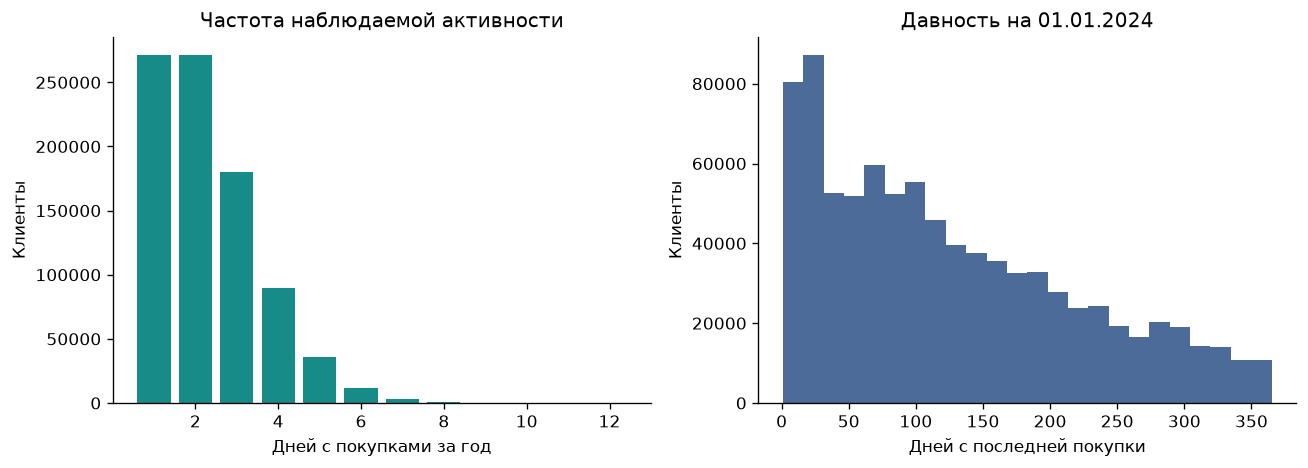

In [2]:
customers=pd.read_csv(DATA/'clients.csv',parse_dates=['first_date','last_date'])
customers['recency_days']=(pd.Timestamp('2024-01-01')-customers.last_date).dt.days
customers['tenure_days']=(pd.Timestamp('2023-12-31')-customers.first_date).dt.days+1
assert customers.client_id.is_unique
monthly=pd.read_csv(DATA/'monthly.csv',parse_dates=['month'])
assert np.isclose(customers.revenue.sum(),monthly.revenue.sum())
display(customers[['revenue','purchase_days','purchase_lines','recency_days']].describe(percentiles=[.25,.5,.75,.9,.95]))
repeat_share=(customers.purchase_days>=2).mean()
display(Markdown(f'Уникальных наблюдаемых клиентов: **{len(customers):,}**. Доля с покупками в два и более разных дня: **{repeat_share:.2%}**. Выручка за 2023 год на одного клиента: **{customers.revenue.mean():,.2f} денежных единиц**.'))
fig,axes=plt.subplots(1,2,figsize=(11,4))
freq=customers.purchase_days.value_counts().sort_index()
axes[0].bar(freq.index,freq.values,color='#178b88')
axes[0].set(xlabel='Дней с покупками за год',ylabel='Клиенты',title='Частота наблюдаемой активности')
axes[1].hist(customers.recency_days,bins=24,color='#4d6b98')
axes[1].set(xlabel='Дней с последней покупки',ylabel='Клиенты',title='Давность на 01.01.2024')
plt.tight_layout();plt.show()

## 2. Когорты и окно наблюдения
В каждой когорте знаменатель — число клиентов, впервые наблюдённых в данном месяце 2023 года. В ячейках — доля этих же клиентов с покупками в соответствующем последующем месяце. Это календарное месячное удержание, а не D30. Будущие для когорты месяцы оставлены пустыми, а не заполнены нулями.

Декабрьскую когорту нельзя сравнивать с январской по годовому M: у них разная длительность наблюдения. Для отдельной метрики возврата за 60 дней берутся только клиенты с первой наблюдаемой покупкой не позднее 01.11.2023. Возврат означает другой день покупки в пределах последующих 60 дней. Ошибки исходных дат могут занижать показатель.

age_month,0,1,2,3,4,5,6,7,8,9,10,11
cohort,,,,,,,,,,,,
2023-01-01,1.00,0.15,0.17,0.14,0.16,0.16,0.16,0.16,0.16,0.15,0.13,0.17
2023-02-01,1.00,0.17,0.14,0.16,0.16,0.16,0.16,0.16,0.16,0.13,0.17,NaN
2023-03-01,1.00,0.14,0.16,0.16,0.16,0.15,0.16,0.16,0.13,0.17,NaN,NaN
2023-04-01,1.00,0.16,0.16,0.16,0.16,0.16,0.15,0.13,0.17,NaN,NaN,NaN
2023-05-01,1.00,0.16,0.16,0.16,0.16,0.16,0.12,0.17,NaN,NaN,NaN,NaN
2023-06-01,1.00,0.16,0.15,0.16,0.15,0.13,0.17,NaN,NaN,NaN,NaN,NaN
2023-07-01,1.00,0.16,0.16,0.16,0.13,0.17,NaN,NaN,NaN,NaN,NaN,NaN
2023-08-01,1.00,0.16,0.16,0.12,0.17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-09-01,1.00,0.16,0.13,0.16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


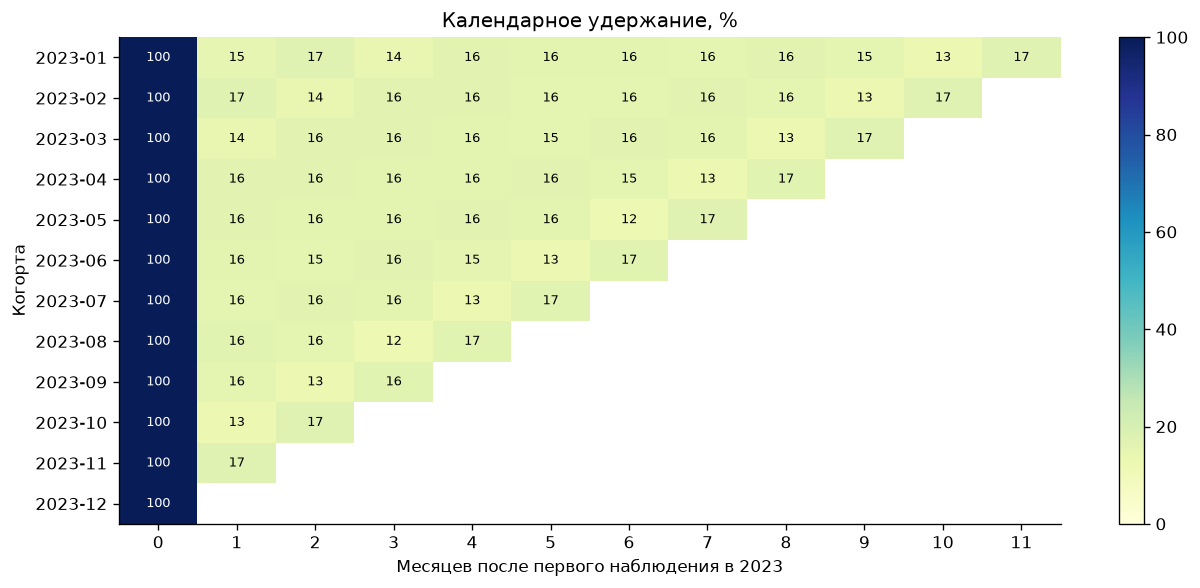

Из **814,715** клиентов с полным 60-дневным окном вернулись **230,950**, то есть **28.35%**. Это описание наблюдаемых данных, не причинный эффект CRM.

In [3]:
cohorts=pd.read_csv(DATA/'cohorts.csv',parse_dates=['cohort','activity_month'])
cohorts['age_month']=(cohorts.activity_month.dt.year-cohorts.cohort.dt.year)*12+cohorts.activity_month.dt.month-cohorts.cohort.dt.month
base=cohorts.loc[cohorts.age_month==0].set_index('cohort').active_clients
cohorts['retention']=cohorts.active_clients/cohorts.cohort.map(base)
retention=cohorts.pivot(index='cohort',columns='age_month',values='retention').reindex(columns=range(12))
for cohort in retention.index:
    last_age=12-cohort.month
    retention.loc[cohort,range(last_age+1)]=retention.loc[cohort,range(last_age+1)].fillna(0)
display(retention)
fig,ax=plt.subplots(figsize=(11,5))
image=ax.imshow(retention.values*100,cmap='YlGnBu',vmin=0,vmax=100,aspect='auto')
ax.set_xticks(range(12),range(12));ax.set_yticks(range(len(retention)),retention.index.strftime('%Y-%m'))
ax.set(xlabel='Месяцев после первого наблюдения в 2023',ylabel='Когорта',title='Календарное удержание, %')
for i in range(len(retention)):
 for j in range(12):
  val=retention.iloc[i,j]
  if pd.notna(val):ax.text(j,i,f'{100*val:.0f}',ha='center',va='center',fontsize=8,color='white' if val>.55 else 'black')
fig.colorbar(image,ax=ax);plt.tight_layout();plt.show()
r60=pd.read_csv(DATA/'repeat_60.csv').iloc[0]
display(Markdown(f'Из **{int(r60.eligible_clients):,}** клиентов с полным 60-дневным окном вернулись **{int(r60.returned_clients):,}**, то есть **{r60.returned_clients/r60.eligible_clients:.2%}**. Это описание наблюдаемых данных, не причинный эффект CRM.'))
retention.to_csv(OUT/'clients_retention.csv',encoding='utf-8-sig')

## 3. Практические сегменты
Правила выбираются до расчёта итогов кампаний, на срезе 01.01.2024. Порог высокой денежной ценности — 75-й перцентиль годового M. Это рабочие правила для пилота, а не статистически оптимальные границы.

- «Вернуть ценных»: M не ниже порога, не менее двух дней с покупками и последняя покупка 90 или более дней назад.
- «Активные ценные»: M не ниже порога, минимум три дня с покупками и R ≤ 30.
- «Недавние однократные»: один день с покупками, R ≤ 30.
- «Остальные»: все другие наблюдаемые клиенты.

Сегменты взаимоисключающие. Нельзя называть всех давно не покупавших ушедшими: нет договорного признака оттока и срока обычного цикла покупки.

Порог M, 75-й перцентиль: 2809638.0


,clients,revenue,mean_purchase_days,median_recency,client_share,revenue_share,revenue_per_client
segment,,,,,,,
Активные ценные,44817,"225,528,929,452.00",4.17,16.00,0.05,0.13,"5,032,218.34"
Вернуть ценных,82933,"383,447,839,621.00",3.07,144.00,0.10,0.23,"4,623,585.78"
Недавние однократные,23743,"19,883,041,741.00",1.00,17.00,0.03,0.01,"837,427.53"
Остальные,712952,"1,045,778,382,466.00",2.14,108.00,0.82,0.62,"1,466,828.60"


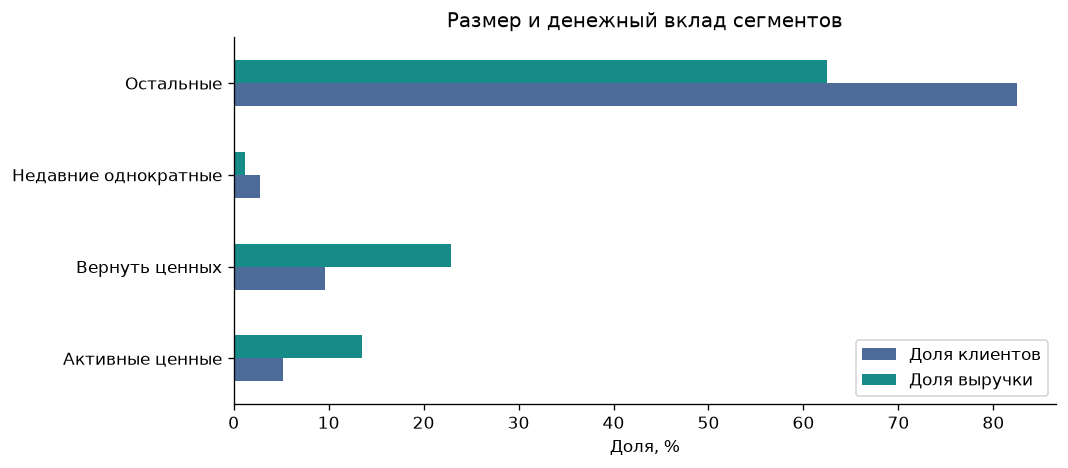

In [4]:
threshold=customers.revenue.quantile(.75)
conditions=[(customers.revenue>=threshold)&(customers.purchase_days>=2)&(customers.recency_days>=90),
 (customers.revenue>=threshold)&(customers.purchase_days>=3)&(customers.recency_days<=30),
 (customers.purchase_days==1)&(customers.recency_days<=30)]
labels=['Вернуть ценных','Активные ценные','Недавние однократные']
customers['segment']=np.select(conditions,labels,default='Остальные')
segments=customers.groupby('segment').agg(clients=('client_id','size'),revenue=('revenue','sum'),
    mean_purchase_days=('purchase_days','mean'),median_recency=('recency_days','median'))
segments['client_share']=segments.clients/len(customers)
segments['revenue_share']=segments.revenue/customers.revenue.sum()
segments['revenue_per_client']=segments.revenue/segments.clients
print('Порог M, 75-й перцентиль:',round(threshold,2))
display(segments)
assert segments.clients.sum()==len(customers)
segments.to_csv(OUT/'clients_segments.csv',encoding='utf-8-sig')
# Individual client lists stay in excluded local data, not in the public report.
customers[['client_id','segment']].to_csv(DATA/'client_segments_private.csv',index=False)
fig,ax=plt.subplots(figsize=(9,4))
segments[['client_share','revenue_share']].mul(100).plot.barh(ax=ax,color=['#4d6b98','#178b88'])
ax.set(xlabel='Доля, %',ylabel='',title='Размер и денежный вклад сегментов');ax.legend(['Доля клиентов','Доля выручки'])
plt.tight_layout();plt.show()

## 4. Две конкретные CRM-проверки

### Кампания A: вернуть ценных клиентов
Целевая группа — сегмент «Вернуть ценных» из таблицы выше. Перед запуском обновить срез на дату кампании, проверить доступность контакта и согласие на коммуникацию. В имеющихся данных контактов и согласий нет; сейчас сформирован только аналитический список ID.

Предложение пилота: персональная подборка из ранее купленных SKU, доступных сейчас, с напоминанием без дополнительной скидки. Контроль — обычное обслуживание без этой коммуникации. Случайное назначение на уровне клиента, 50/50, один клиент закрепляется в одной группе. Основная метрика — доля клиентов с покупкой в следующие 30 дней. Дополнительные — выручка и маржинальный доход на всех назначенных клиентов, отписки, жалобы и возвраты. Не анализировать только открывших сообщение или только купивших: это разрушает случайность сравнения.

### Кампания B: вторая покупка у недавних однократных
Целевая группа — «Недавние однократные». На 7-й день после первого наблюдаемого дня покупки, если повторной покупки ещё нет, протестировать подборку дополняющих товаров по истории совместных покупок. Для исторического среза это предложение механики, а не уже выполненная кампания. В текущем API нет заказа и товарных категорий: перед запуском нужен товарный справочник и события корзины, чтобы не подбирать случайные ID.

Основная метрика — повторный день покупки в течение 30 дней после назначения. Защитные метрики — маржинальный доход на клиента, отписки и возвраты. Измерять эффект по всем назначенным клиентам; учитывать клиентов без покупки как нулевой результат.

Для обеих кампаний размер выборки считается до запуска по базовой конверсии подходящего сегмента и минимально полезному приросту. Исторический показатель возврата за 60 дней не подставляется как готовая 30-дневная конверсия кампании: окна и аудитории различаются. Разделить аудитории двух тестов или учесть пересечение в дизайне.

### Как оценить денежный масштаб без обещания результата
Ниже сценарий: в каждом сегменте доля повторно купивших увеличилась на 1 процентный пункт. Сначала рассчитывается дополнительное число клиентов. Денежный эквивалент использует среднюю историческую выручку на клиентский день покупки всей базы. Это грубая иллюстрация: возвращённые клиенты могут иметь другой размер покупки. Из выручки ещё нужно вычесть себестоимость, расходы кампании и скидки; их нет в источнике.

In [5]:
revenue_per_client_day=customers.revenue.sum()/customers.purchase_days.sum()
scenario=segments.loc[segments.index.isin(['Вернуть ценных','Недавние однократные']),['clients']].copy()
scenario['assumed_lift_pp']=1.0
scenario['extra_returning_clients']=scenario.clients*.01
scenario['illustrative_extra_revenue']=scenario.extra_returning_clients*revenue_per_client_day
display(scenario)
scenario.to_csv(OUT/'clients_scenarios.csv',encoding='utf-8-sig')
display(Markdown(f'Историческая выручка на клиентский день покупки: **{revenue_per_client_day:,.2f} денежных единиц**. Это не средний чек заказа и не прогноз выручки кампании.'))

,clients,assumed_lift_pp,extra_returning_clients,illustrative_extra_revenue
segment,,,,
Вернуть ценных,82933,1.00,829.33,"696,835,349.26"
Недавние однократные,23743,1.00,237.43,"199,497,928.42"


Историческая выручка на клиентский день покупки: **840,238.93 денежных единиц**. Это не средний чек заказа и не прогноз выручки кампании.

## 5. Что увеличивать и как связать это с LTV
Приоритет — **дополнительный маржинальный доход на клиента**, а не число рассылок, скидок или товарных строк. Повторная покупка полезна, если её вклад перекрывает стоимость стимулирования и не заменяет покупку, которая произошла бы без кампании. Именно для этого нужен контроль.

Для полноценного LTV добавить: дату привлечения и источник, стоимость привлечения, ID заказа, себестоимость, возвраты, затраты доставки и CRM, полную историю клиента. После этого строить накопленный маржинальный доход когорт на одинаковом возрасте и учитывать неполное наблюдение молодых когорт. Экстраполировать один год выручки на произвольное число лет нельзя.

Метрики мониторинга: активные клиенты за месяц; повторный день покупки в фиксированном окне; выручка и затем маржинальный доход на клиента; возраст когорты; доля исключённых строк; полнота календаря загрузки. Внедрять одновременно крупные изменения цен и CRM без раздельного дизайна не стоит: станет трудно объяснить результат.

## Итог
Сформированы конкретные взаимоисключающие сегменты и два проекта кампаний с аудиторией, механикой, контрольной группой и метриками. Численность и денежный вклад находятся в `clients_segments.csv`, сценарные расчёты — в `clients_scenarios.csv`. Ни один сценарий не представлен как измеренный эффект: эксперименты не проводились.

Ограничения: ошибки исходных дат, наблюдение только 2023 года, неизвестная история до окна, отсутствие контактов и себестоимости. Главный следующий шаг — связать очищенные покупки с надёжным справочником клиентов и заказов, затем проверить кампании на обновлённых данных.